# E-Commerce Review Prediction
**Author:** Hunter Sarkis  
**Dataset:** Olist Brazilian E-Commerce Public Dataset  
**Framework:** CRISP-DM

---

## Abstract
This project applies the CRISP-DM framework to analyze 100,000+ e-commerce orders from Olist, a Brazilian online retail marketplace. The business objective is to predict whether a customer will leave a negative review based on order characteristics such as price, freight cost, delivery time, and product category. By identifying the key drivers of dissatisfaction, retailers can proactively intervene before a bad review is submitted.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


## Step 2: Load & Merge Data

We load the six relevant CSV files and merge them into one master dataframe.
Each order becomes one row with its price, freight, payment type, product category,
review score, and review comment.

In [2]:
# Load CSVs
orders    = pd.read_csv('olist_orders_dataset.csv')
items     = pd.read_csv('olist_order_items_dataset.csv')
reviews   = pd.read_csv('olist_order_reviews_dataset.csv')
payments  = pd.read_csv('olist_order_payments_dataset.csv')
products  = pd.read_csv('olist_products_dataset.csv')
cat_trans = pd.read_csv('product_category_name_translation.csv')

# Aggregate items per order (one row per order)
items_agg = items.groupby('order_id').agg(
    price=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
    product_id=('product_id', 'first')
).reset_index()

# Aggregate payments per order
payments_agg = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_type=('payment_type', 'first')
).reset_index()

# Translate product categories to English
products_cat = products.merge(cat_trans, on='product_category_name', how='left')

# One review per order
reviews_dedup = reviews.drop_duplicates(subset='order_id', keep='first')

# Build master dataframe
df = (orders
      .merge(reviews_dedup[['order_id','review_score','review_comment_message']], on='order_id', how='inner')
      .merge(items_agg, on='order_id', how='left')
      .merge(payments_agg, on='order_id', how='left')
      .merge(products_cat[['product_id','product_category_name_english']], on='product_id', how='left')
     )

df.rename(columns={'product_category_name_english': 'product_category'}, inplace=True)

print('Master dataframe shape:', df.shape)
df.head()

Master dataframe shape: (98673, 16)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_comment_message,price,freight_value,product_id,payment_value,payment_type,product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,4,"Não testei o produto ainda, mas ele veio corre...",29.99,8.72,87285b34884572647811a353c7ac498a,38.71,credit_card,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,4,Muito bom o produto.,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,141.46,boleto,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,5,NaN,159.90,19.22,aa4383b373c6aca5d8797843e5594415,179.12,credit_card,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,5,O produto foi exatamente o que eu esperava e e...,45.00,27.20,d0b61bfb1de832b15ba9d266ca96e5b0,72.20,credit_card,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,5,NaN,19.90,8.72,65266b2da20d04dbe00c5c2d3bb7859e,28.62,credit_card,stationery


## Step 3: Data Cleaning & Feature Engineering

The following cleaning steps are applied:
1. Parse datetime columns and engineer `delivery_days` and `days_early_late`
2. Filter to delivered orders only
3. Impute missing values (median for numeric, mode for categorical)
4. Cap outliers using IQR fencing
5. Bin low-count product categories into 'other'
6. Create the binary label `satisfied`

In [3]:
# 1. Parse datetimes & engineer delivery features
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['days_early_late'] = (df['order_estimated_delivery_date'] - df['order_delivered_customer_date']).dt.days

# 2. Filter to delivered orders only
before = len(df)
df = df[df['order_status'] == 'delivered'].copy()
print(f'Rows before: {before:,} | After filtering to delivered: {len(df):,} | Removed: {before - len(df):,}')

# 3. Impute missing values
for col in ['price', 'freight_value', 'payment_value', 'delivery_days', 'days_early_late']:
    df[col].fillna(df[col].median(), inplace=True)

for col in ['payment_type', 'product_category']:
    df[col].fillna(df[col].mode()[0], inplace=True)

df['review_comment_message'].fillna('', inplace=True)
print('Missing values imputed.')

# 4. Cap outliers using IQR fencing
def iqr_cap(series, factor=3.0):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(Q1 - factor * IQR, Q3 + factor * IQR)

for col in ['price', 'freight_value', 'delivery_days']:
    df[col] = iqr_cap(df[col])
print('Outliers capped.')

# 5. Bin low-count product categories
counts = df['product_category'].value_counts()
low = counts[counts < 300].index
df['product_category'] = df['product_category'].apply(lambda x: 'other' if x in low else x)
print(f'Product categories retained: {df["product_category"].nunique()}')

# 6. Create binary label
df['satisfied'] = (df['review_score'] >= 4).astype(int)
print(f'\nLabel distribution:\n{df["satisfied"].value_counts()}')
print(f'\nSatisfied rate: {df["satisfied"].mean()*100:.1f}%')

Rows before: 98,673 | After filtering to delivered: 95,832 | Removed: 2,841
Missing values imputed.
Outliers capped.
Product categories retained: 32

Label distribution:
satisfied
1    75657
0    20175
Name: count, dtype: int64

Satisfied rate: 78.9%


## Step 4: Univariate Statistics & Visualizations (Descriptive Analytics)

Descriptive analytics answers the question: **"What happened?"**

Univariate analysis examines each feature individually. The four most influential
features are analyzed along with the label `satisfied`.

In [4]:
# Univariate statistics for numeric features
numeric_features = ['delivery_days', 'days_early_late', 'price', 'satisfied']

rows = []
for col in numeric_features:
    s = df[col]
    rows.append({
        'Feature': col,
        'Count': s.count(),
        'Missing': s.isna().sum(),
        'Unique': s.nunique(),
        'Min': round(s.min(), 2),
        'Q1': round(s.quantile(0.25), 2),
        'Median': round(s.median(), 2),
        'Q3': round(s.quantile(0.75), 2),
        'Max': round(s.max(), 2),
        'Mean': round(s.mean(), 2),
        'Std': round(s.std(), 2),
        'Mode': round(s.mode()[0], 2),
        'Skewness': round(s.skew(), 3),
        'Kurtosis': round(s.kurt(), 3)
    })

stats_df = pd.DataFrame(rows).set_index('Feature')
stats_df

,Count,Missing,Unique,Min,Q1,Median,Q3,Max,Mean,Std,Mode,Skewness,Kurtosis
Feature,,,,,,,,,,,,,
delivery_days,95832,0,43,0.00,6.0,10.00,15.0,42.0,11.85,8.21,7.0,1.498,2.508
days_early_late,95832,0,196,-189.00,6.0,11.00,16.0,146.0,10.91,10.11,13.0,-1.942,27.254
price,95832,0,6236,0.85,45.9,86.25,149.9,461.9,119.84,108.74,461.9,1.731,2.586
satisfied,95832,0,2,0.00,1.0,1.00,1.0,1.0,0.79,0.41,1.0,-1.420,0.017


In [5]:
# Univariate statistics for categorical feature: payment_type
s = df['payment_type']
print('=== payment_type ===')
print(f'Count:   {s.count():,}')
print(f'Missing: {s.isna().sum()}')
print(f'Unique:  {s.nunique()}')
print(f'Mode:    {s.mode()[0]}')
print()
print(s.value_counts())

=== payment_type ===
Count:   95,832
Missing: 0
Unique:  4
Mode:    credit_card

payment_type
credit_card    72733
boleto         19062
voucher         2559
debit_card      1478
Name: count, dtype: int64


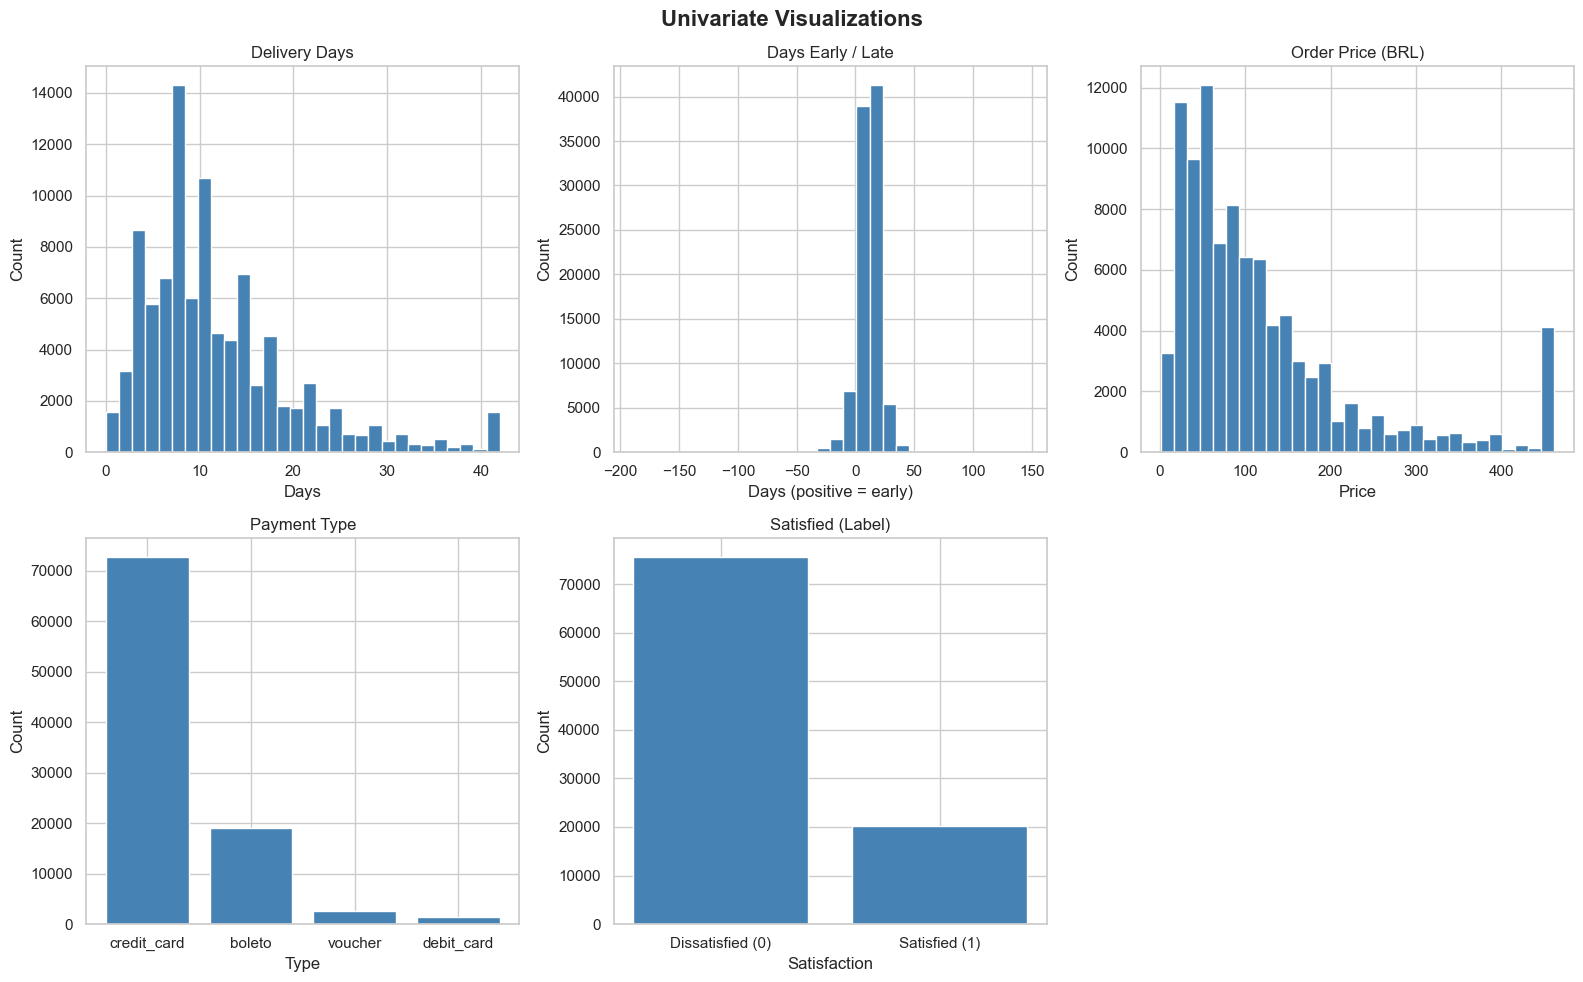

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Univariate Visualizations', fontsize=16, fontweight='bold')

# delivery_days histogram
axes[0,0].hist(df['delivery_days'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Delivery Days')
axes[0,0].set_xlabel('Days')
axes[0,0].set_ylabel('Count')

# days_early_late histogram
axes[0,1].hist(df['days_early_late'], bins=30, color='steelblue', edgecolor='white')
axes[0,1].set_title('Days Early / Late')
axes[0,1].set_xlabel('Days (positive = early)')
axes[0,1].set_ylabel('Count')

# price histogram
axes[0,2].hist(df['price'], bins=30, color='steelblue', edgecolor='white')
axes[0,2].set_title('Order Price (BRL)')
axes[0,2].set_xlabel('Price')
axes[0,2].set_ylabel('Count')

# payment_type count plot
payment_counts = df['payment_type'].value_counts()
axes[1,0].bar(payment_counts.index, payment_counts.values, color='steelblue', edgecolor='white')
axes[1,0].set_title('Payment Type')
axes[1,0].set_xlabel('Type')
axes[1,0].set_ylabel('Count')

# satisfied count plot
satisfied_counts = df['satisfied'].value_counts()
axes[1,1].bar(['Dissatisfied (0)', 'Satisfied (1)'], satisfied_counts.values, color='steelblue', edgecolor='white')
axes[1,1].set_title('Satisfied (Label)')
axes[1,1].set_xlabel('Satisfaction')
axes[1,1].set_ylabel('Count')

# hide unused subplot
axes[1,2].set_visible(False)

plt.tight_layout()
plt.show()

## Step 5: Bivariate Statistics & Visualizations (Diagnostic Analytics)

Diagnostic analytics answers the question: **"Why did this happen?"**

Since `satisfied` is a categorical label (0 or 1), we use:
- **t-test** for numeric features (delivery_days, days_early_late, price)
- **Chi-square** for categorical features (payment_type)

Each test tells us whether the feature has a statistically significant relationship with satisfaction.

In [7]:
# t-tests for numeric features vs satisfied
numeric_feats = ['delivery_days', 'days_early_late', 'price']

print('=== t-tests: Numeric Features vs Satisfied ===\n')
for col in numeric_feats:
    satisfied = df[df['satisfied'] == 1][col]
    dissatisfied = df[df['satisfied'] == 0][col]
    t_stat, p_val = stats.ttest_ind(satisfied, dissatisfied)
    print(f'{col}:')
    print(f'  Satisfied mean:    {satisfied.mean():.2f}')
    print(f'  Dissatisfied mean: {dissatisfied.mean():.2f}')
    print(f'  t-statistic: {t_stat:.3f}  |  p-value: {p_val:.4f}')
    print(f'  Significant: {"Yes" if p_val < 0.05 else "No"}\n')

# Chi-square for payment_type vs satisfied
print('=== Chi-Square: payment_type vs Satisfied ===\n')
contingency = pd.crosstab(df['payment_type'], df['satisfied'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(contingency)
print(f'\nChi2: {chi2:.3f}  |  p-value: {p:.4f}  |  Degrees of Freedom: {dof}')
print(f'Significant: {"Yes" if p < 0.05 else "No"}')

=== t-tests: Numeric Features vs Satisfied ===

delivery_days:
  Satisfied mean:    10.56
  Dissatisfied mean: 16.71
  t-statistic: -99.354  |  p-value: 0.0000
  Significant: Yes

days_early_late:
  Satisfied mean:    12.13
  Dissatisfied mean: 6.34
  t-statistic: 74.362  |  p-value: 0.0000
  Significant: Yes

price:
  Satisfied mean:    117.89
  Dissatisfied mean: 127.14
  t-statistic: -10.743  |  p-value: 0.0000
  Significant: Yes

=== Chi-Square: payment_type vs Satisfied ===

satisfied         0      1
payment_type              
boleto         4033  15029
credit_card   15288  57445
debit_card      278   1200
voucher         576   1983

Chi2: 7.914  |  p-value: 0.0478  |  Degrees of Freedom: 3
Significant: Yes


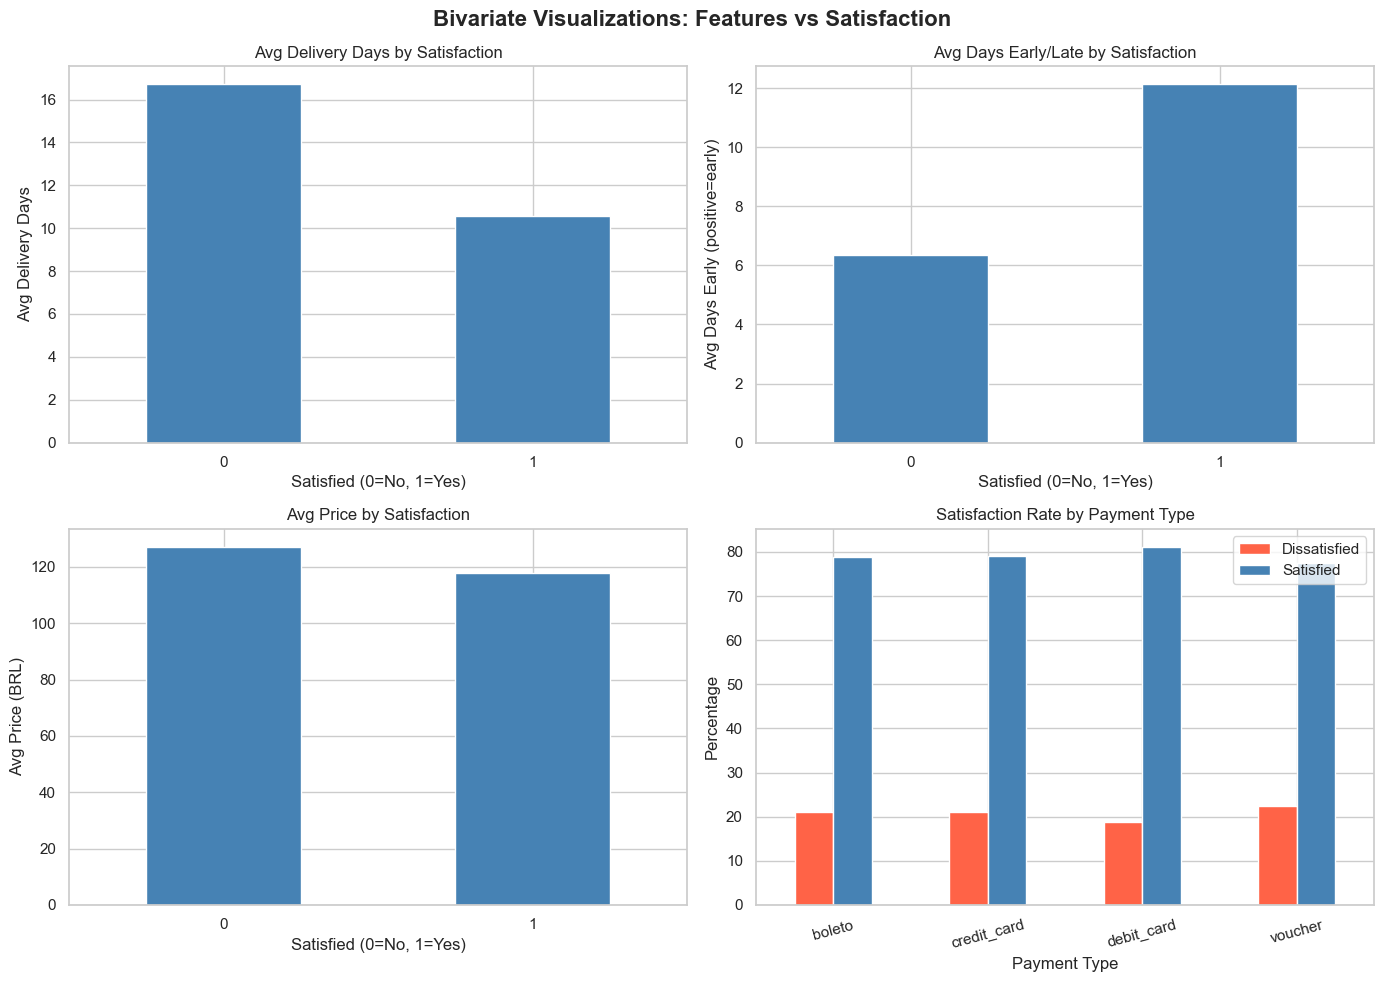

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bivariate Visualizations: Features vs Satisfaction', fontsize=16, fontweight='bold')

# delivery_days vs satisfied
df.groupby('satisfied')['delivery_days'].mean().plot(
    kind='bar', ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Avg Delivery Days by Satisfaction')
axes[0,0].set_xlabel('Satisfied (0=No, 1=Yes)')
axes[0,0].set_ylabel('Avg Delivery Days')
axes[0,0].tick_params(axis='x', rotation=0)

# days_early_late vs satisfied
df.groupby('satisfied')['days_early_late'].mean().plot(
    kind='bar', ax=axes[0,1], color='steelblue', edgecolor='white')
axes[0,1].set_title('Avg Days Early/Late by Satisfaction')
axes[0,1].set_xlabel('Satisfied (0=No, 1=Yes)')
axes[0,1].set_ylabel('Avg Days Early (positive=early)')
axes[0,1].tick_params(axis='x', rotation=0)

# price vs satisfied
df.groupby('satisfied')['price'].mean().plot(
    kind='bar', ax=axes[1,0], color='steelblue', edgecolor='white')
axes[1,0].set_title('Avg Price by Satisfaction')
axes[1,0].set_xlabel('Satisfied (0=No, 1=Yes)')
axes[1,0].set_ylabel('Avg Price (BRL)')
axes[1,0].tick_params(axis='x', rotation=0)

# payment_type vs satisfied (contingency)
contingency_pct = pd.crosstab(df['payment_type'], df['satisfied'], normalize='index') * 100
contingency_pct.plot(kind='bar', ax=axes[1,1], color=['tomato','steelblue'], edgecolor='white')
axes[1,1].set_title('Satisfaction Rate by Payment Type')
axes[1,1].set_xlabel('Payment Type')
axes[1,1].set_ylabel('Percentage')
axes[1,1].legend(['Dissatisfied', 'Satisfied'])
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()